In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt


In [19]:
data = pd.read_csv(r"C:\Users\Bharati Gupta\OneDrive\Desktop\CLG_P_DA\Placement_Data_Full_Class.csv")
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [22]:
data.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [23]:
data = data.drop_duplicates()

In [25]:
data.columns = ['SlNo','Gender','SSC_P','SSC_B','HSC_P','HSC_B','HSC_S','Degree_P','Degree_T','WorkEx','ETest_P','Specialisation','MBA_P','Status','Salary']


In [27]:
placement_counts = data['Status'].value_counts()
print(placement_counts)

Status
Placed        148
Not Placed     67
Name: count, dtype: int64


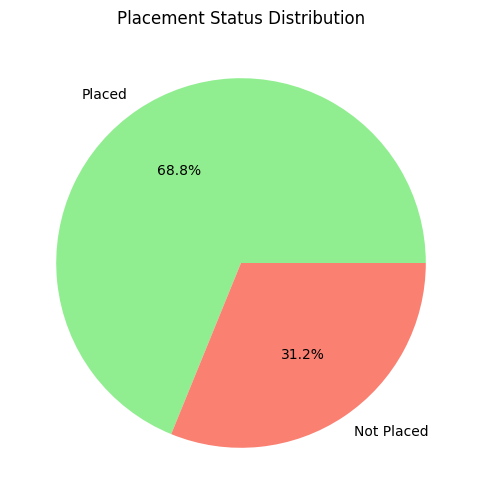

In [28]:
# Pie chart of placement status
plt.figure(figsize=(6,6))
placement_counts.plot.pie(autopct='%1.1f%%', colors=['lightgreen','salmon'])
plt.title('Placement Status Distribution')
plt.ylabel('')
plt.show()


In [29]:
# Count of placements by gender
gender_placement = data.groupby(['Gender','Status']).size().unstack()
print(gender_placement)


Status  Not Placed  Placed
Gender                    
F               28      48
M               39     100


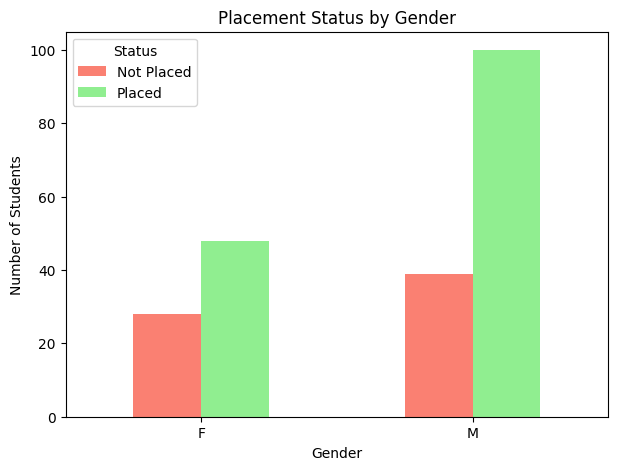

In [30]:
# Bar chart: Gender vs Placement
gender_placement.plot(kind='bar', figsize=(7,5), color=['salmon','lightgreen'])
plt.title('Placement Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()


In [31]:
# Average percentages by placement status
avg_marks = data[['SSC_P','HSC_P','Degree_P','MBA_P','Status']].groupby('Status').mean()
print(avg_marks)


                SSC_P      HSC_P   Degree_P      MBA_P
Status                                                
Not Placed  57.544030  58.395522  61.134179  61.612836
Placed      71.721486  69.926554  68.740541  62.579392


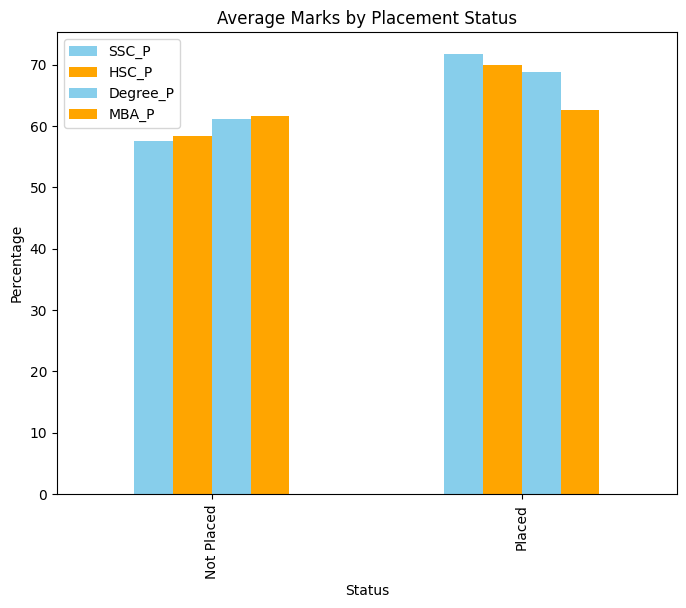

In [32]:
# Bar chart for average marks by placement
avg_marks.plot(kind='bar', figsize=(8,6), color=['skyblue','orange'])
plt.title('Average Marks by Placement Status')
plt.ylabel('Percentage')
plt.show()


In [33]:
# Count of placements by work experience
workex_placement = data.groupby(['WorkEx','Status']).size().unstack()
print(workex_placement)


Status  Not Placed  Placed
WorkEx                    
No              57      84
Yes             10      64


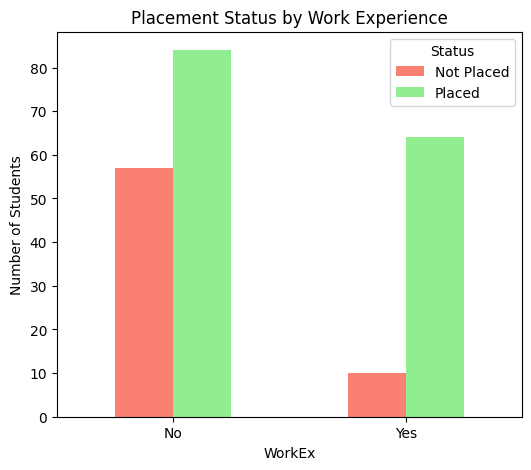

In [34]:
# Bar chart: Work Experience vs Placement
workex_placement.plot(kind='bar', figsize=(6,5), color=['salmon','lightgreen'])
plt.title('Placement Status by Work Experience')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()


In [35]:
# Count of placements by MBA Specialisation
spec_placement = data.groupby(['Specialisation','Status']).size().unstack()
print(spec_placement)


Status          Not Placed  Placed
Specialisation                    
Mkt&Fin                 25      95
Mkt&HR                  42      53


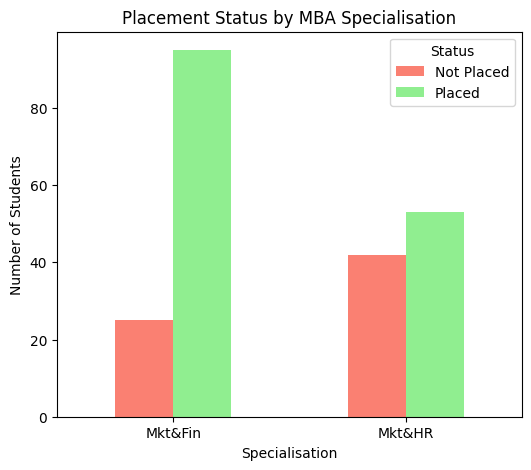

In [36]:
# Bar chart: Specialisation vs Placement
spec_placement.plot(kind='bar', figsize=(6,5), color=['salmon','lightgreen'])
plt.title('Placement Status by MBA Specialisation')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()


In [37]:
# Count of placements by 10th board
ssc_board_placement = data.groupby(['SSC_B','Status']).size().unstack()
print(ssc_board_placement)


Status   Not Placed  Placed
SSC_B                      
Central          38      78
Others           29      70


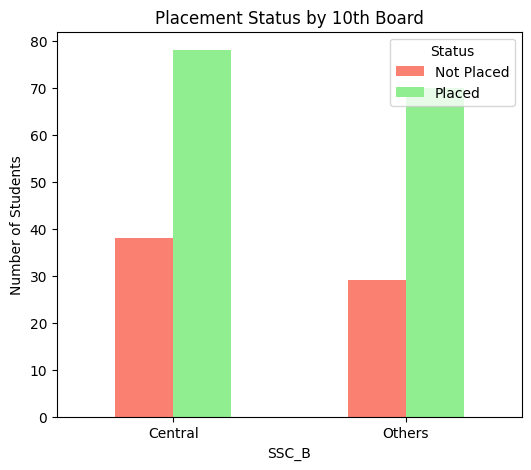

In [39]:
# Bar chart: SSC Board vs Placement
ssc_board_placement.plot(kind='bar', figsize=(6,5), color=['salmon','lightgreen'])
plt.title('Placement Status by 10th Board')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()


In [40]:
hsc_board_placement = data.groupby(['HSC_B','Status']).size().unstack()
print(hsc_board_placement)

Status   Not Placed  Placed
HSC_B                      
Central          27      57
Others           40      91


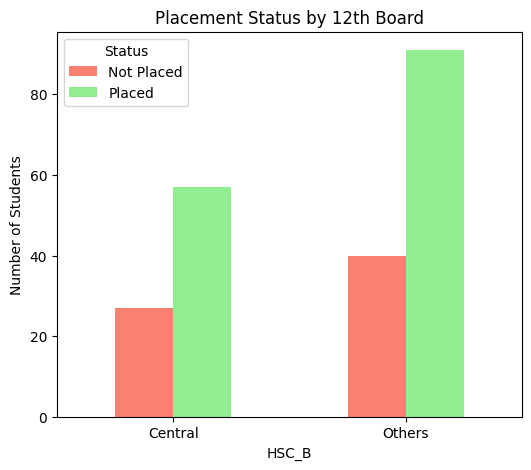

In [41]:
hsc_board_placement.plot(kind='bar', figsize=(6,5), color=['salmon','lightgreen'])
plt.title('Placement Status by 12th Board')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

In [43]:
# Filter only placed students
placed_students = data[data['Status'] == 'Placed']

# Basic salary stats
salary_stats = placed_students['Salary'].describe()
print(salary_stats)


count       148.000000
mean     288655.405405
std       93457.452420
min      200000.000000
25%      240000.000000
50%      265000.000000
75%      300000.000000
max      940000.000000
Name: Salary, dtype: float64


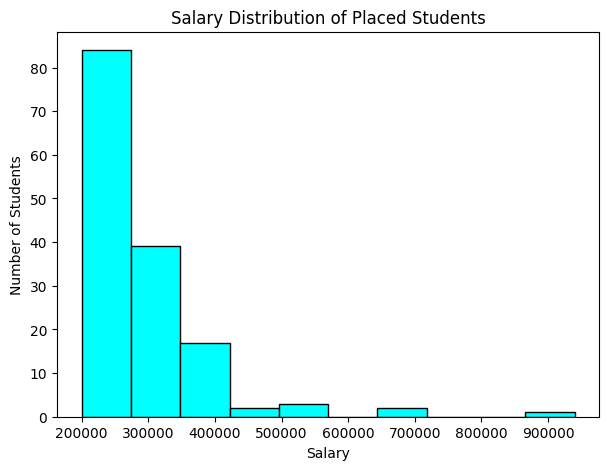

In [46]:
# Histogram of salary
plt.figure(figsize=(7,5))
plt.hist(placed_students['Salary'], bins=10, color='cyan', edgecolor='black')
plt.title('Salary Distribution of Placed Students')
plt.xlabel('Salary')
plt.ylabel('Number of Students')
plt.show()


In [50]:
# 1) Column names clean (remove extra spaces)
data.columns = data.columns.str.strip()

# 2) Print columns to confirm exact names
print(list(data.columns))


['SlNo', 'Gender', 'SSC_P', 'SSC_B', 'HSC_P', 'HSC_B', 'HSC_S', 'Degree_P', 'Degree_T', 'WorkEx', 'ETest_P', 'Specialisation', 'MBA_P', 'Status', 'Salary']


In [52]:
print(data.columns)


Index(['SlNo', 'Gender', 'SSC_P', 'SSC_B', 'HSC_P', 'HSC_B', 'HSC_S',
       'Degree_P', 'Degree_T', 'WorkEx', 'ETest_P', 'Specialisation', 'MBA_P',
       'Status', 'Salary'],
      dtype='object')


In [53]:
cols = ['SSC_P','HSC_P','Degree_P','ETest_P','MBA_P','Salary']

for c in cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')

print(data[cols].isnull().sum())


SSC_P        0
HSC_P        0
Degree_P     0
ETest_P      0
MBA_P        0
Salary      67
dtype: int64


In [54]:
numeric_data = data[cols].dropna()   # drop rows where any of these are missing
correlation_matrix = numeric_data.corr()
correlation_matrix


,SSC_P,HSC_P,Degree_P,ETest_P,MBA_P,Salary
SSC_P,1.000000,0.293416,0.380657,0.317892,0.430560,0.035330
HSC_P,0.293416,1.000000,0.221307,0.284672,0.329983,0.076819
Degree_P,0.380657,0.221307,1.000000,0.217683,0.494093,-0.019272
ETest_P,0.317892,0.284672,0.217683,1.000000,0.284143,0.178307
MBA_P,0.430560,0.329983,0.494093,0.284143,1.000000,0.175013
Salary,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


In [55]:
print(data.columns)

Index(['SlNo', 'Gender', 'SSC_P', 'SSC_B', 'HSC_P', 'HSC_B', 'HSC_S',
       'Degree_P', 'Degree_T', 'WorkEx', 'ETest_P', 'Specialisation', 'MBA_P',
       'Status', 'Salary'],
      dtype='object')


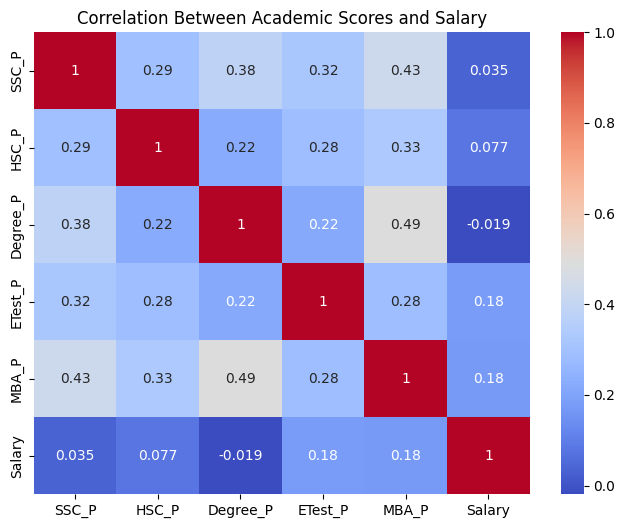

In [56]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Academic Scores and Salary')
plt.show()
